# MULTISPECTOR — RF-DETR Segmentation Nano POC

End-to-end flow: `image/video → DINOv2 backbone → RF-DETR segmentation head → masks + boxes + grain classes`.

Run one code cell at a time, inspect its output, then continue. The model is loaded in section 7, fine-tuned in section 8, evaluated in section 9, and tested visually in section 10.

## 1. Paths and imports

In [1]:
from pathlib import Path
import importlib.metadata as metadata
import platform
import sys
import time

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATASET_DIR = PROJECT_ROOT / 'wheatdecv1_seg'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'rfdetr_seg_nano'
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display

from multispector_rfdetr import audit_dataset, plot_class_balance, plot_yolo_samples

assert DATASET_DIR.exists(), f'Dataset not found: {DATASET_DIR}'
print(f'Project: {PROJECT_ROOT}')
print(f'Dataset: {DATASET_DIR}')
print(f'Outputs: {OUTPUT_DIR}')

Project: /home/multispector2/testdino
Dataset: /home/multispector2/testdino/wheatdecv1_seg
Outputs: /home/multispector2/testdino/outputs/rfdetr_seg_nano


## 2. Environment and CUDA check

Dataset inspection can run on CPU. RF-DETR setup, fine-tuning, and speed tests should run on CUDA.

In [3]:
environment = {
    'Python': platform.python_version(),
    'PyTorch': torch.__version__,
    'RF-DETR': metadata.version('rfdetr'),
    'CUDA build': torch.version.cuda,
    'CUDA available': torch.cuda.is_available(),
}
if torch.cuda.is_available():
    properties = torch.cuda.get_device_properties(0)
    environment['GPU'] = properties.name
    environment['VRAM (GB)'] = round(properties.total_memory / 1024**3, 2)
display(pd.DataFrame(environment.items(), columns=['Item', 'Value']))
assert torch.cuda.is_available(), 'CUDA is not available. Do not start fine-tuning on CPU.'
test_tensor = torch.randn(512, 512, device='cuda')
print(f'CUDA tensor test passed on {test_tensor.device}.')
del test_tensor
torch.cuda.empty_cache()

,Item,Value
0,Python,3.12.11
1,PyTorch,2.13.0+cu126
2,RF-DETR,1.9.3
3,CUDA build,12.6
4,CUDA available,True
5,GPU,NVIDIA RTX 4000 SFF Ada Generation
6,VRAM (GB),19.55


CUDA tensor test passed on cuda:0.


## 3. Dataset audit

This checks split pairing, class balance, polygon structure, dense images, and likely source leakage. Set `deep_coordinate_check=True` for a slower full coordinate-range validation.

In [4]:
report = audit_dataset(DATASET_DIR, deep_coordinate_check=False)
CLASS_NAMES = report['class_names']
display(Markdown(f"**Classes:** `{CLASS_NAMES}`"))
display(report['summary'])
display(report['class_counts'])
display(report['source_overlaps'])
if report['issues'].empty:
    print('No image/label pairing or polygon-structure problems were found.')
else:
    display(report['issues'].head(50))

**Classes:** `['bad seed', 'healthy seed', 'impurity']`

,split,images,instances,instances/image mean,instances/image p95,instances/image max,images > 100 instances
0,train,3459,216071,62.5,209,616,573
1,valid,217,14240,65.6,226,334,42
2,test,82,4485,54.7,125,262,14


,split,class_id,class_name,instances,percentage
0,train,0,bad seed,146129,67.630
1,train,1,healthy seed,67937,31.442
2,train,2,impurity,2005,0.928
3,valid,0,bad seed,9670,67.907
4,valid,1,healthy seed,4486,31.503
5,valid,2,impurity,84,0.590
6,test,0,bad seed,3095,69.008
7,test,1,healthy seed,1345,29.989
8,test,2,impurity,45,1.003


,split_pair,likely_shared_sources,examples
0,train/valid,41,"20220804_102414_jpg, train_wheat_101_jpg, trai..."
1,train/test,0,
2,valid/test,0,


No image/label pairing or polygon-structure problems were found.


### 3.1 Labeled instance counts

This table shows exactly how many labeled instances exist for each class in every dataset split and in total.

In [5]:
grain_counts = (
    report['class_counts']
    .pivot(index='class_name', columns='split', values='instances')
    .reindex(index=CLASS_NAMES, columns=['train', 'valid', 'test'], fill_value=0)
    .fillna(0)
    .astype(int)
)
grain_counts['total'] = grain_counts.sum(axis=1)
grain_counts.loc['ALL LABELED INSTANCES'] = grain_counts.sum(axis=0)
display(
    grain_counts.style
    .format('{:,}')
    .set_caption('Labeled grain/impurity instances by class and split')
)

split,train,valid,test,total
class_name,,,,
bad seed,"146,129","9,670","3,095","158,894"
healthy seed,"67,937","4,486","1,345","73,768"
impurity,"2,005",84,45,"2,134"
ALL LABELED INSTANCES,"216,071","14,240","4,485","234,796"


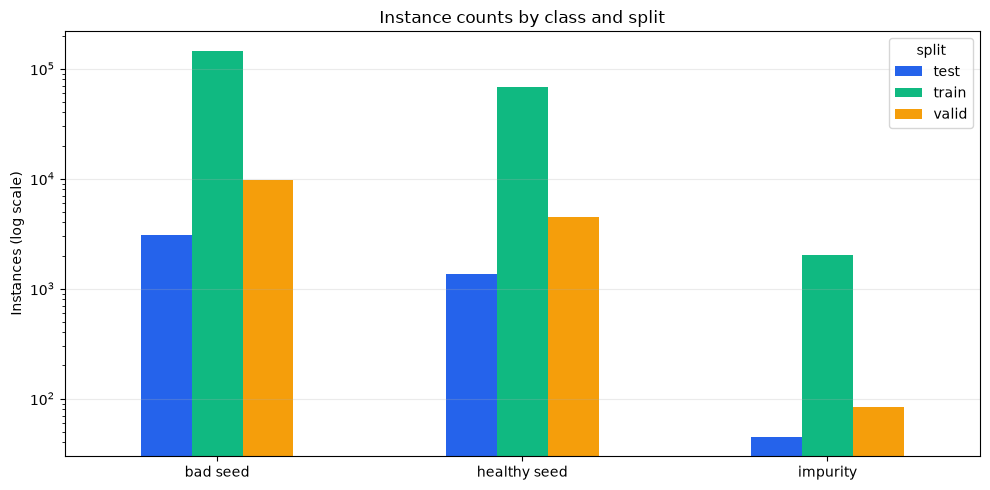

In [6]:
plot_class_balance(report['class_counts'], log_scale=True)

## 4. Ground-truth mask visualization

Inspect random samples, then force a sample containing the rare `impurity` class. Masks should hug individual objects and touching grains should remain separate instances.

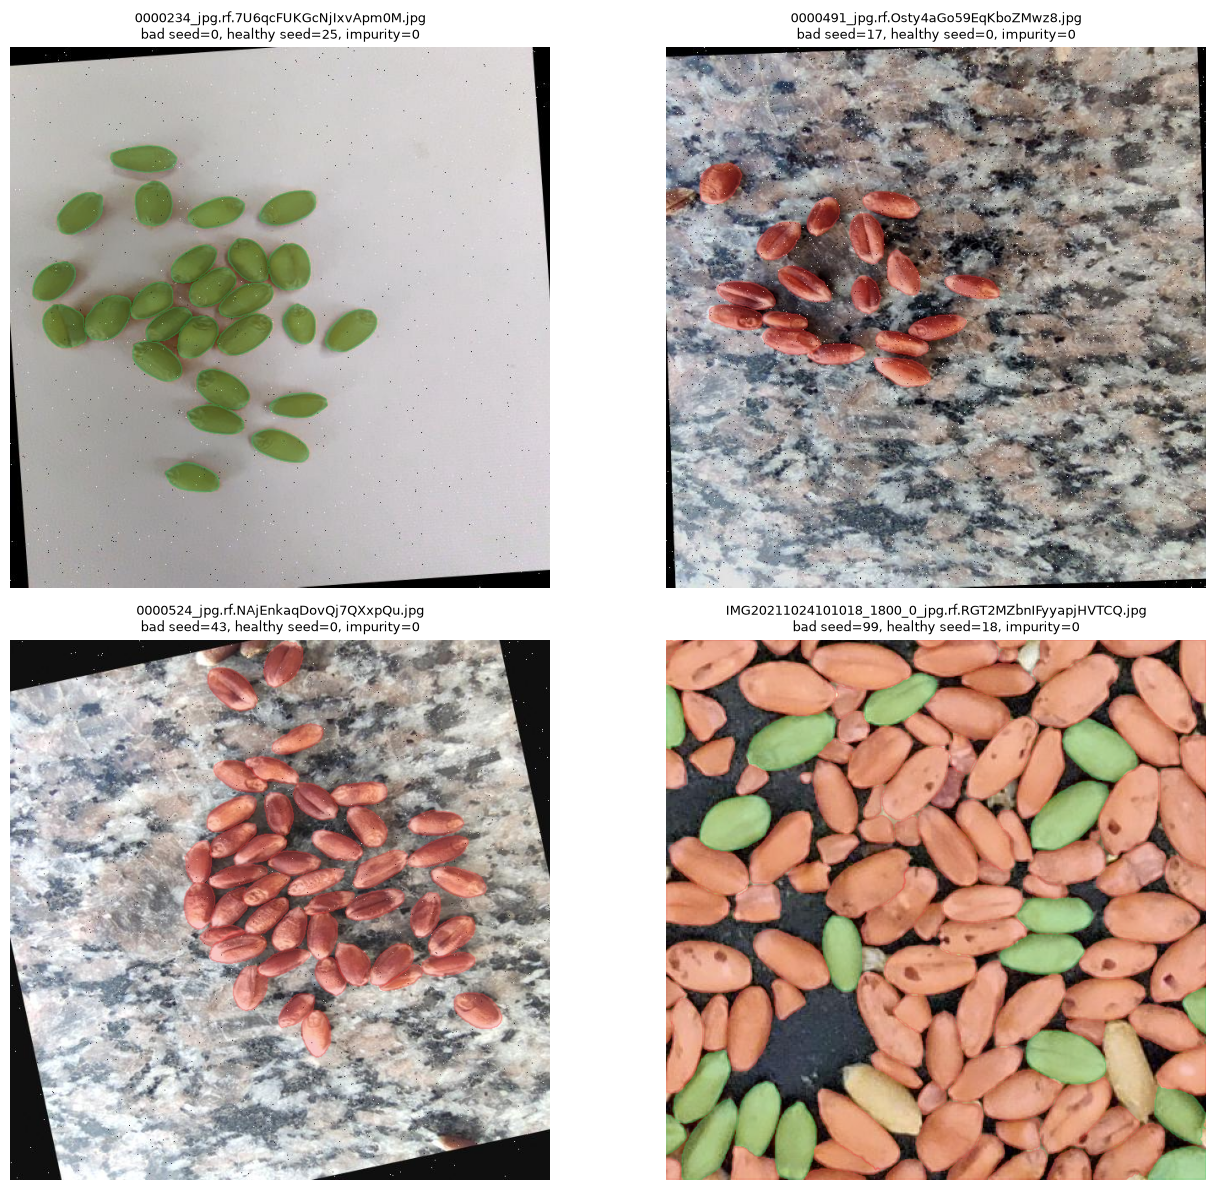

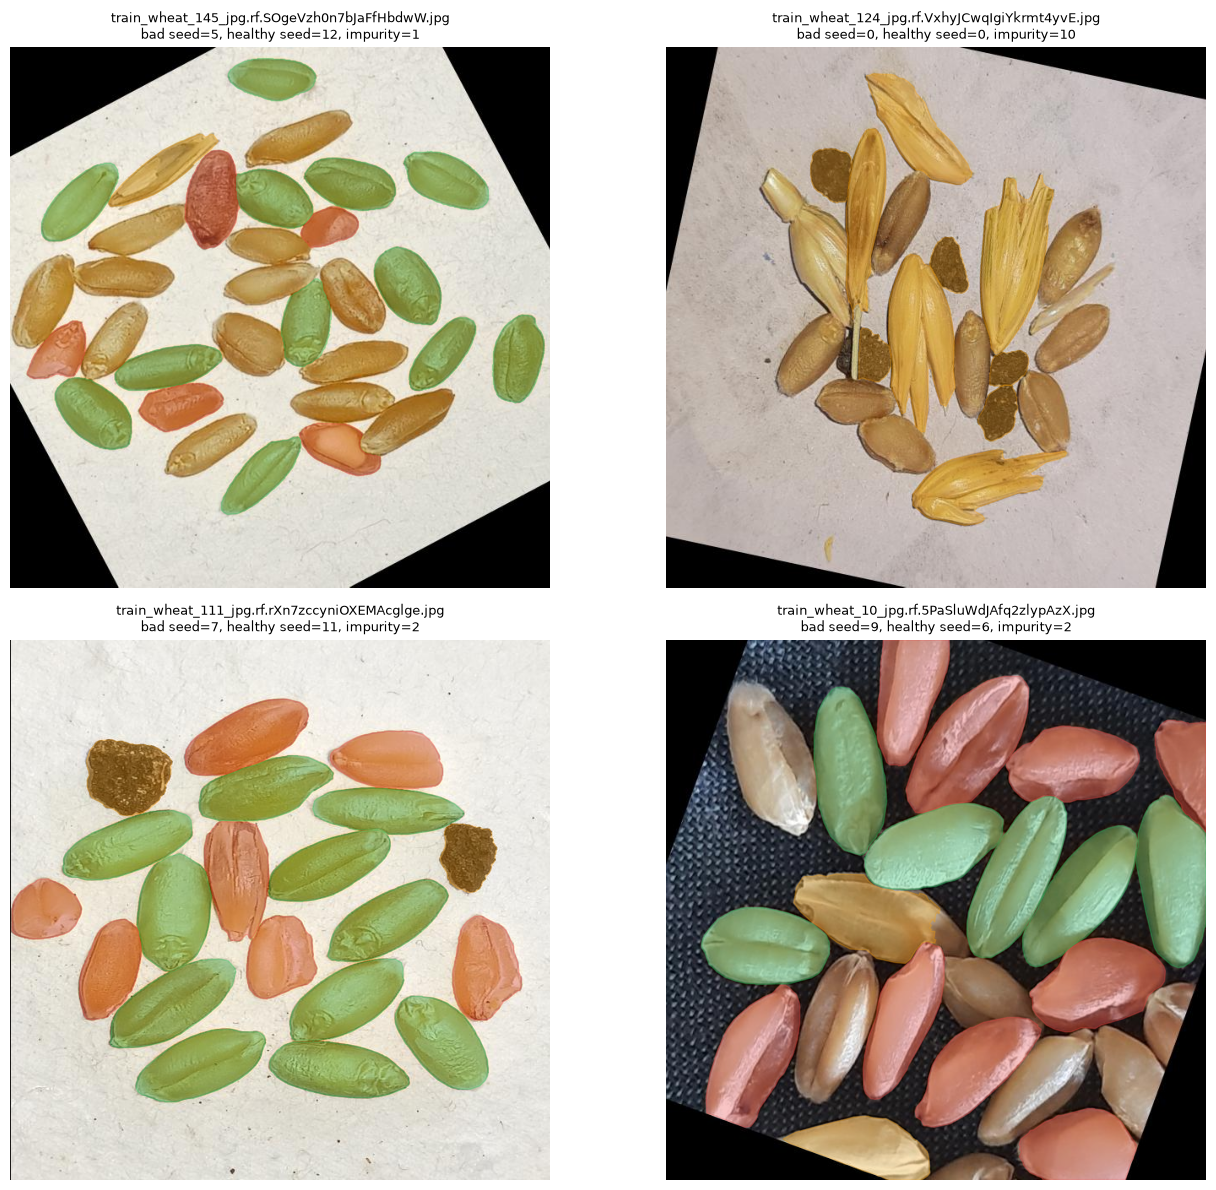

In [7]:
plot_yolo_samples(DATASET_DIR, split='train', count=4, seed=7)
impurity_id = CLASS_NAMES.index('impurity')
plot_yolo_samples(DATASET_DIR, split='train', count=4, seed=11, class_id=impurity_id)

## 5. RF-DETR Nano capacity check

RF-DETR Seg Nano uses 100 object queries by default, so one full-frame prediction cannot return more than 100 instances. Dense images should eventually be tiled/cropped, or the query count and memory budget must be redesigned.

In [8]:
MODEL_NUM_QUERIES = 100
density = (
    report['per_image']
    .groupby('split')['instances']
    .agg(['count', 'mean', 'median', 'max'])
)
density['images_over_query_limit'] = report['per_image'].groupby('split')['instances'].apply(
    lambda values: int((values > MODEL_NUM_QUERIES).sum())
)
display(density)
dense_train = int(((report['per_image']['split'] == 'train') & (report['per_image']['instances'] > MODEL_NUM_QUERIES)).sum())
if dense_train:
    display(Markdown(
        f"⚠️ **{dense_train} training images exceed Nano's {MODEL_NUM_QUERIES}-query output capacity.** "
        "Training can be explored, but full-frame recall is capped. Tiling is the recommended next dataset step."
    ))

,count,mean,median,max,images_over_query_limit
split,,,,,
test,82,54.695122,36.5,262,14
train,3459,62.466320,39.0,616,573
valid,217,65.622120,48.0,334,42


⚠️ **573 training images exceed Nano's 100-query output capacity.** Training can be explored, but full-frame recall is capped. Tiling is the recommended next dataset step.

## 6. Training settings

These conservative defaults are selected for the 4GB GPU: Nano's default resolution 312, micro-batch 1, accumulated gradients, no EMA copy, and gradient checkpointing. Running this cell only defines the settings; it does not start training.

In [9]:
RESOLUTION = 312             # Nano default; divisible by 12.
BATCH_SIZE = 4               # Safe starting point for 4GB VRAM.
GRAD_ACCUM_STEPS = 4        # Effective batch size = 16.
EPOCHS = 30                  # Train all epochs; best validation checkpoint is saved automatically.
LEARNING_RATE = 1e-4
BACKBONE_LEARNING_RATE = 5e-5
NUM_WORKERS = 4              # Robust default for Jupyter on Windows.

config_table = pd.DataFrame({
    'parameter': ['resolution', 'batch_size', 'grad_accum_steps', 'effective_batch', 'epochs', 'lr', 'lr_encoder'],
    'value': [RESOLUTION, BATCH_SIZE, GRAD_ACCUM_STEPS, BATCH_SIZE * GRAD_ACCUM_STEPS, EPOCHS, LEARNING_RATE, BACKBONE_LEARNING_RATE],
})
display(config_table)

,parameter,value
0,resolution,312.00000
1,batch_size,4.00000
2,grad_accum_steps,4.00000
3,effective_batch,16.00000
4,epochs,30.00000
5,lr,0.00010
6,lr_encoder,0.00005


## 7. Load RF-DETR Segmentation Nano

The constructor downloads Roboflow's official COCO-pretrained segmentation checkpoint. Fine-tuning replaces/adapts the classification head for our three grain classes while preserving the pretrained DINOv2 visual features.

In [10]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano(
    num_classes=len(CLASS_NAMES),
    resolution=RESOLUTION,
    gradient_checkpointing=False,
)
print(f'Model loaded: {type(model).__name__}')
print(f'Resolution: {model.model_config.resolution}')
print(f'Classes: {CLASS_NAMES}')

/home/multispector2/testdino/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-08-24 11:44:03] [INFO] rf-detr - Downloading pretrained weights for /home/multispector2/.roboflow/models/rf-detr-seg-nano.pt


/home/multispector2/.roboflow/models/rf-detr-seg-nano.pt: 100%|██████████| 128M/128M [00:08<00:00, 16.7MiB/s] 


[2026-08-24 11:44:12] [INFO] rf-detr - MD5 validation successful for /home/multispector2/.roboflow/models/rf-detr-seg-nano.pt


[2026-08-24 11:44:12] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-24 11:44:12] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-24 11:44:12] [INFO] rf-detr - File /home/multispector2/.roboflow/models/rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-08-24 11:44:12] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 3. The detection head will be re-initialized to 3 classes.


Model loaded: RFDETRSegNano
Resolution: 312
Classes: ['bad seed', 'healthy seed', 'impurity']


## 8. Fine-tune

Running the next cell starts the long GPU fine-tuning process. The integrated model learns `bad seed`, `healthy seed`, and `impurity` directly; there is no additional classifier afterward. Do not run it until sections 1–7 have completed successfully.

In [11]:
assert model is not None, 'Run section 7 first.'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.train(
    dataset_dir=str(DATASET_DIR),
    output_dir=str(OUTPUT_DIR),
    device='cuda',
    resolution=RESOLUTION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    lr_encoder=BACKBONE_LEARNING_RATE,
    num_workers=NUM_WORKERS,
    use_ema=False,
    early_stopping=False,
    checkpoint_interval=1,
    run_test=False,
    log_per_class_metrics=True,
    compute_val_loss=True,
    scale_jitter=False,
    save_dataset_grids=True,
)
BEST_CHECKPOINT = OUTPUT_DIR / 'checkpoint_best_regular.pth'
assert BEST_CHECKPOINT.exists(), f'Best checkpoint was not created: {BEST_CHECKPOINT}'
print(f'Best validation checkpoint: {BEST_CHECKPOINT}')

Val (Epoch 30/30) — Overall Metrics                        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃     segm mAP    ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │ 50:95  │   50   │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.6928 │ 0.7801 │ 0.7512 │ 0.7263 │ 0.8277 │ 0.9106 │ 0.7602 │ 0.6335 │ 0.7851 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┘
              Val (Epoch 30/30) — Per-class Metrics               
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class        ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ bad seed     │   0.5984 │ 0.6242 │ 0.7902 │    0.9136 │ 0.6962 │
│ healthy seed │   0.7471 │ 0.7713 │ 0.8543 │    0.9027 │ 0.8107 │
│ impurity     │   0.7329 │ 0.7833 │ 0.8387 │    0.9155 │ 0.7738 │
└──────────────┴──────────┴────────┴────────┴───────────┴────────┘

`Trainer.fit` stopped: `max_epochs=30` reached.


[2026-08-24 14:10:47] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.6373, ema=0.0000)
Best validation checkpoint: /home/multispector2/testdino/outputs/rfdetr_seg_nano/checkpoint_best_regular.pth


## 9. Training curves and test metrics

In [20]:
# For Test

from pathlib import Path
import shutil
import yaml

dataset_root = Path(DATASET_DIR).resolve()
yaml_path = dataset_root / "data.yaml"
backup_path = dataset_root / "data.yaml.backup"


if not backup_path.exists():
    shutil.copy2(yaml_path, backup_path)


with yaml_path.open("r", encoding="utf-8") as file:
    dataset_config = yaml.safe_load(file)


dataset_config["train"] = "train/images"
dataset_config["val"] = "valid/images"
dataset_config["test"] = "test/images"


with yaml_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(
        dataset_config,
        file,
        sort_keys=False,
        allow_unicode=True
    )

print(f"Updated: {yaml_path}")


for split_name in ["train", "val", "test"]:
    split_path = (dataset_root / dataset_config[split_name]).resolve()
    print(f"{split_name}: {split_path}")
    print(f"Exists: {split_path.exists()}")

Updated: /home/multispector2/wheat_quality_project/dataset_segmented/wheatdecv1_seg/wheatdecv1_seg/data.yaml
train: /home/multispector2/wheat_quality_project/dataset_segmented/wheatdecv1_seg/wheatdecv1_seg/train/images
Exists: True
val: /home/multispector2/wheat_quality_project/dataset_segmented/wheatdecv1_seg/wheatdecv1_seg/valid/images
Exists: True
test: /home/multispector2/wheat_quality_project/dataset_segmented/wheatdecv1_seg/wheatdecv1_seg/test/images
Exists: True


In [22]:
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd


# ---------------------------------------------------------
# 1. Display training metrics and important curves
# ---------------------------------------------------------
metric_files = (
    sorted(
        OUTPUT_DIR.rglob("metrics.csv"),
        key=lambda path: path.stat().st_mtime
    )
    if OUTPUT_DIR.exists()
    else []
)

if metric_files:
    metrics_path = metric_files[-1]
    metrics_frame = pd.read_csv(metrics_path)

    print(f"Metrics file: {metrics_path}")
    display(metrics_frame.tail())

    # Only plot the most useful metrics.
    preferred_columns = [
        "train/loss",
        "val/loss",
        "val/mAP_50_95",
        "val/segm_mAP_50_95",
        "val/F1",
        "val/precision",
        "val/recall",
        "val/AP/bad seed",
        "val/AP/healthy seed",
        "val/AP/impurity",
    ]

    curve_columns = [
        column
        for column in preferred_columns
        if column in metrics_frame.columns
        and metrics_frame[column].notna().any()
    ]

    if curve_columns:
        selected_columns = curve_columns.copy()

        if "epoch" in metrics_frame.columns:
            selected_columns = ["epoch"] + selected_columns

        plot_frame = metrics_frame[selected_columns].copy()

        # Combine multiple logging rows belonging to the same epoch.
        if "epoch" in plot_frame.columns:
            plot_frame = (
                plot_frame
                .groupby("epoch", as_index=False)
                .last()
            )

        plot_frame = plot_frame.dropna(
            subset=curve_columns,
            how="all"
        )

        plot_frame.plot(
            x="epoch" if "epoch" in plot_frame.columns else None,
            y=curve_columns,
            subplots=True,
            figsize=(12, 3 * len(curve_columns)),
            grid=True,
            marker="o",
            legend=True,
        )

        plt.tight_layout()
        plt.show()

    else:
        print("No supported training curves were found in metrics.csv.")

else:
    print("No metrics.csv file was found.")


# ---------------------------------------------------------
# 2. Load the best validation checkpoint
# ---------------------------------------------------------
BEST_CHECKPOINT = OUTPUT_DIR / "checkpoint_best_regular.pth"

assert BEST_CHECKPOINT.exists(), (
    f"Best checkpoint not found: {BEST_CHECKPOINT}"
)

print(f"Loading best checkpoint: {BEST_CHECKPOINT}")

model = RFDETRSegNano.from_checkpoint(
    str(BEST_CHECKPOINT)
)


# ---------------------------------------------------------
# 3. Evaluate the best model on the test split
# ---------------------------------------------------------
print("Evaluating the best model on the test dataset...")

test_metrics = model.evaluate(
    dataset_dir=str(DATASET_DIR),
    split="test",
    device="cuda",
    batch_size=1,
)

print("Test evaluation finished.")

if isinstance(test_metrics, dict):
    test_metrics_frame = pd.DataFrame(
        test_metrics.items(),
        columns=["metric", "value"]
    )
    display(test_metrics_frame)
else:
    display(test_metrics)

Test (Epoch 1/100) — Overall Metrics                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃     segm mAP    ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │ 50:95  │   50   │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.6721 │ 0.7603 │ 0.7246 │ 0.7272 │ 0.8043 │ 0.8621 │ 0.7554 │ 0.6313 │ 0.7651 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┘
              Test (Epoch 1/100) — Per-class Metrics              
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class        ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ bad seed     │   0.6057 │ 0.6417 │ 0.7817 │    0.8716 │ 0.7086 │
│ healthy seed │   0.6490 │ 0.7044 │ 0.7504 │    0.7661 │ 0.7353 │
│ impurity     │   0.7617 │ 0.8356 │ 0.8810 │    0.9487 │ 0.8222 │
└──────────────┴──────────┴────────┴────────┴───────────┴────────┘

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test/AP/bad seed      │    0.6056656837463379     │
│   test/AP/healthy seed    │    0.6490455269813538     │
│     test/AP/impurity      │     0.761652410030365     │
│          test/F1          │    0.8043368458747864     │
│         test/loss         │     5.607195854187012     │
│        test/mAP_50        │    0.7603389024734497     │
│      test/mAP_50_95       │    0.6721212267875671     │
│        test/mAP_75        │    0.7245588898658752     │
│         test/mAR          │    0.7272289991378784     │
│      test/precision       │    0.8621374368667603     │
│        test/recall        │    0.7553668022155762     │
│     test/segm_mAP_50      │    0.7651397585868835     │
│    test/segm_mAP_50_95    │    0.6313311457633972     │
└───────────────────────────┴───────────────────────────┘

Test evaluation finished.


,metric,value
0,test/loss,5.607196
1,test/mAP_50_95,0.672121
2,test/mAP_50,0.760339
3,test/mAP_75,0.724559
4,test/mAR,0.727229
5,test/segm_mAP_50_95,0.631331
6,test/segm_mAP_50,0.765140
7,test/F1,0.804337
8,test/precision,0.862137
9,test/recall,0.755367


## 10. Visual inference and latency

Use a test image to inspect masks, boxes, labels, confidence, and approximate CUDA inference time.

[2026-08-24 14:30:17] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


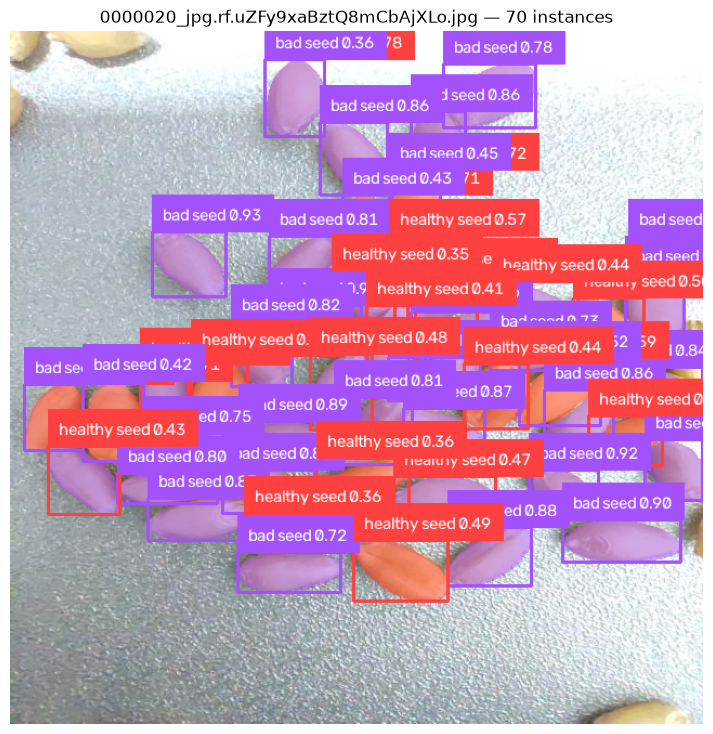

Mean end-to-end latency: 28.4 ms | Approx. FPS: 35.2


In [23]:
import supervision as sv

assert model is not None, 'Complete model setup and training first.'
image_path = sorted((DATASET_DIR / 'test' / 'images').glob('*'))[0]
image_bgr = cv2.imread(str(image_path))
detections = model.predict(image_bgr, threshold=0.35)
labels = [
    f'{CLASS_NAMES[int(class_id)]} {confidence:.2f}'
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]
annotated = sv.MaskAnnotator().annotate(image_bgr.copy(), detections)
annotated = sv.BoxAnnotator().annotate(annotated, detections)
annotated = sv.LabelAnnotator().annotate(annotated, detections, labels=labels)
plt.figure(figsize=(12, 9))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f'{image_path.name} — {len(detections)} instances')
plt.axis('off')
plt.show()

for _ in range(3):
    model.predict(image_bgr, threshold=0.35)
torch.cuda.synchronize()
timings = []
for _ in range(20):
    started = time.perf_counter()
    model.predict(image_bgr, threshold=0.35)
    torch.cuda.synchronize()
    timings.append((time.perf_counter() - started) * 1000)
mean_ms = sum(timings) / len(timings)
print(f'Mean end-to-end latency: {mean_ms:.1f} ms | Approx. FPS: {1000 / mean_ms:.1f}')

## 11. Jetson deployment checkpoint

Do not optimize for Jetson before validating mask/class quality. After selecting the best `.pth` checkpoint, the deployment stage should export ONNX, build TensorRT on the target Jetson, and benchmark FP16 (then INT8 only if accuracy remains acceptable). Tiled inference must be included if full camera frames can contain more than 100 grains.